In [2]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
from enum import Enum
from datetime import timedelta

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

In [38]:

# [numLinks, seconds]

class RP(Enum):
    ECMP = 1

class FP(Enum):
    MAX_MIN = 1



class Run:
    def __init__(self, rp: RP, fp: FP, tm: timedelta, links: int, events: int, ev_per_batch: float, nodes: int, hosts: int):
        self.rp: RP = rp
        self.fp: FP = fp
        self.tm: timedelta = tm
        self.links: int = links
        self.events: int = events
        self.ev_per_batch: float = ev_per_batch
        self.nodes: int = nodes
        self.hosts: int = hosts


# OLD =======================================
# # Fat Tree runs with fixed num of events (avg of 5 runs).
# data_var_top: list[Run] = [
#     Run(RP.ECMP, FP.MAX_MIN, tm = timedelta(seconds=1.472), links=184, events=3072000, ev_per_batch=256, nodes=37, hosts=16), #FatTree(3, 4)   BASE
#     Run(RP.ECMP, FP.MAX_MIN, tm = timedelta(seconds=3.009), links=621, events=3072000, ev_per_batch=256, nodes = 100, hosts=54), #FatTree(3, 6) (*3.375 links)
#     Run(RP.ECMP, FP.MAX_MIN, tm = timedelta(seconds=5.881), links=1472, events=3072000, ev_per_batch=256, nodes=209, hosts=128), #FatTree(3, 8) (*8 links)
#     Run(RP.ECMP, FP.MAX_MIN, tm = timedelta(seconds=13.277), links=2875, events=3072000, ev_per_batch=256, nodes=376, hosts=250), #FatTree(3, 10) (*15.625 links)
#     Run(RP.ECMP, FP.MAX_MIN, tm = timedelta(seconds=29.641), links=4968, events=3072000, ev_per_batch=256, nodes=613, hosts=432), #FatTree(3, 12) (*27 links)
#     Run(RP.ECMP, FP.MAX_MIN, tm = timedelta(seconds=61.086), links=7889, events=3072000, ev_per_batch=256, nodes=932, hosts=686), #FatTree(3, 14) (*42.875 links)
#     Run(RP.ECMP, FP.MAX_MIN, tm = timedelta(seconds=112.626), links=11776, events=3072000, ev_per_batch=256, nodes=1345, hosts=1024), #FatTree(3, 16) (*64 links)
# ]

# # Fat tree runs with fixed topology (avg of 5 runs).
# data_var_events: list[Run] = [
#     Run(RP.ECMP, FP.MAX_MIN, tm = timedelta(seconds=1.472), links=184, events=3072000, ev_per_batch=256, nodes=37, hosts=16), #FatTree(3, 4)  BASE
#     Run(RP.ECMP, FP.MAX_MIN, tm = timedelta(seconds=4.898), links=184, events=10368000 , ev_per_batch=2, nodes=37, hosts=16), #FatTree(3, 4)
#     Run(RP.ECMP, FP.MAX_MIN, tm = timedelta(seconds=11.500), links=184, events=24576000, ev_per_batch=2, nodes=37, hosts=16), #FatTree(3, 4)
#     Run(RP.ECMP, FP.MAX_MIN, tm = timedelta(seconds=22.856), links=184, events=48000000, ev_per_batch=2, nodes=37, hosts=16), #FatTree(3, 4)
#     Run(RP.ECMP, FP.MAX_MIN, tm = timedelta(seconds=39.744), links=184, events=82944000, ev_per_batch=2, nodes=37, hosts=16), #FatTree(3, 4)
#     Run(RP.ECMP, FP.MAX_MIN, tm = timedelta(seconds=63.513), links=184, events=131712000, ev_per_batch=256, nodes=37, hosts=16), #FatTree(3, 4)
#     Run(RP.ECMP, FP.MAX_MIN, tm = timedelta(seconds=94.297), links=184, events=196608000, ev_per_batch=256, nodes=37, hosts=16), #FatTree(3, 4)
# ]
# OLD =======================================


# Fat Tree runs with fixed num of events (avg of 5 runs).
data_var_top: list[Run] = [
    Run(RP.ECMP, FP.MAX_MIN, tm = timedelta(seconds=1.2), links=184, events=322020, ev_per_batch=256, nodes=37, hosts=16), #FatTree(3, 4)   BASE
    Run(RP.ECMP, FP.MAX_MIN, tm = timedelta(seconds=7.45), links=621, events=985142, ev_per_batch=256, nodes = 100, hosts=54), #FatTree(3, 6) (*3.375 links)
    Run(RP.ECMP, FP.MAX_MIN, tm = timedelta(seconds=23.43), links=1472, events=1156397, ev_per_batch=256, nodes=209, hosts=128), #FatTree(3, 8) (*8 links)
    Run(RP.ECMP, FP.MAX_MIN, tm = timedelta(seconds=62.90), links=2875, events=4637582, ev_per_batch=256, nodes=376, hosts=250), #FatTree(3, 10) (*15.625 links)
    Run(RP.ECMP, FP.MAX_MIN, tm = timedelta(seconds=126.33), links=4968, events=8135934, ev_per_batch=256, nodes=613, hosts=432), #FatTree(3, 12) (*27 links)
]

# Fat tree runs with fixed topology (avg of 5 runs).
data_var_events: list[Run] = [
    Run(RP.ECMP, FP.MAX_MIN, tm = timedelta(seconds=1.472), links=184, events=3072000, ev_per_batch=256, nodes=37, hosts=16), #FatTree(3, 4)  BASE
    Run(RP.ECMP, FP.MAX_MIN, tm = timedelta(seconds=4.898), links=184, events=10368000 , ev_per_batch=2, nodes=37, hosts=16), #FatTree(3, 4)
    Run(RP.ECMP, FP.MAX_MIN, tm = timedelta(seconds=11.500), links=184, events=24576000, ev_per_batch=2, nodes=37, hosts=16), #FatTree(3, 4)
    Run(RP.ECMP, FP.MAX_MIN, tm = timedelta(seconds=22.856), links=184, events=48000000, ev_per_batch=2, nodes=37, hosts=16), #FatTree(3, 4)
    Run(RP.ECMP, FP.MAX_MIN, tm = timedelta(seconds=39.744), links=184, events=82944000, ev_per_batch=2, nodes=37, hosts=16), #FatTree(3, 4)
    Run(RP.ECMP, FP.MAX_MIN, tm = timedelta(seconds=63.513), links=184, events=131712000, ev_per_batch=256, nodes=37, hosts=16), #FatTree(3, 4)
    Run(RP.ECMP, FP.MAX_MIN, tm = timedelta(seconds=94.297), links=184, events=196608000, ev_per_batch=256, nodes=37, hosts=16), #FatTree(3, 4)
]

<Figure size 1200x720 with 0 Axes>

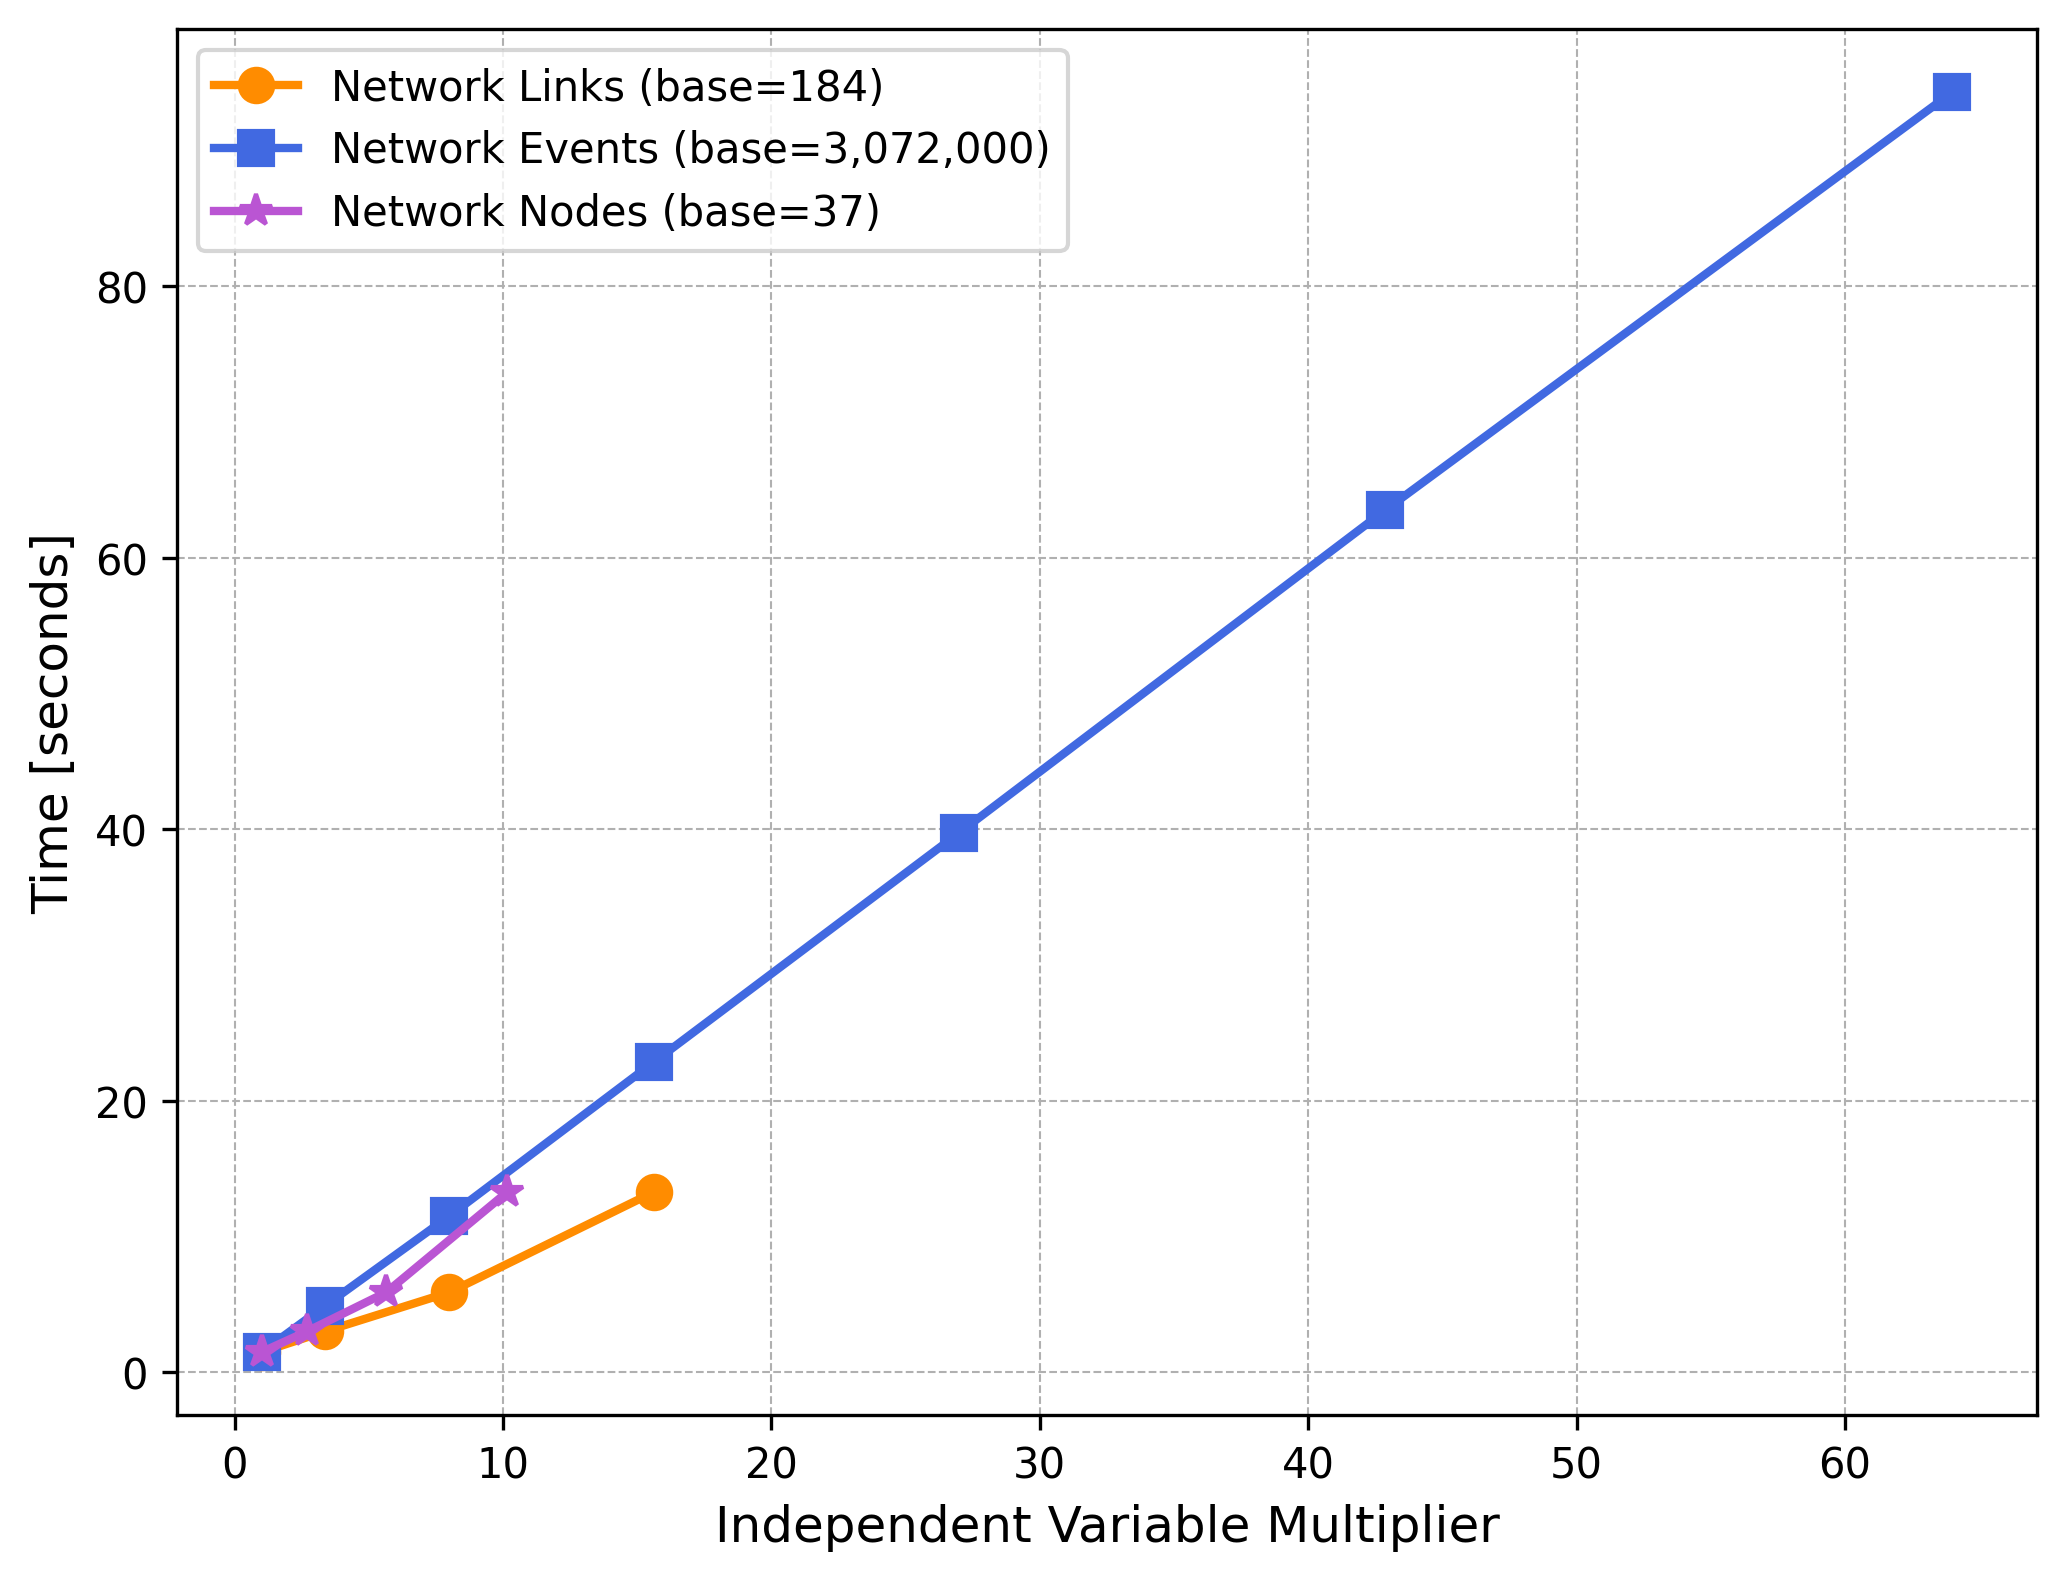

In [9]:
def bo():
    base_links: int = data_var_top[0].links
    link_scaling: list[float] = [x.tm.total_seconds() for x in data_var_top]
    link_scaling_x: list[float] = [x.links / base_links  for x in data_var_top]

    base_events: int = data_var_events[0].events
    event_scaling: list[float] = [x.tm.total_seconds() for x in data_var_events]
    event_scaling_x: list[float] = [x.events / base_events for x in data_var_events]

    # base_link_per_node: float = data_var_links[0].links / data_var_links[0].nodes
    # link_per_node_scaling: list[float] = [x.tm.total_seconds() for x in data_var_links]
    # link_per_node_scaling_x: list[float] = [x.links / x.nodes for x in data_var_links]

    node_scaling_base: int = data_var_top[0].nodes
    node_scaling: list[float] = [x.tm.total_seconds() for x in data_var_top]
    node_scaling_x: list[float] = [x.nodes / node_scaling_base for x in data_var_top]

    host_scaling_base: int = data_var_top[0].hosts
    host_scaling: list[float] = [x.tm.total_seconds() for x in data_var_top]
    host_scaling_x: list[float] = [x.hosts / host_scaling_base for x in data_var_top]


    data = [
        (link_scaling, link_scaling_x, "darkorange", "o", "Network Links (base=184)"),
        (event_scaling, event_scaling_x,  "royalblue", "s", "Network Events (base=3,072,000)"),
        # (link_per_node_scaling, link_per_node_scaling_x,  "red", "*", "Network Events (base=3,072,000)"),
        (node_scaling, node_scaling_x,  "mediumorchid", "*", "Network Nodes (base=37)"),
        # (host_scaling, host_scaling_x,  "cyan", "v", "Network Hosts (base=16)"),
    ]

    
    plt.figure(figsize=(5 * 8/10, 3 * 8/10))
    # Create the figure and axis
    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot each dataset
    for y, x, color, marker, label in data:
        ax.plot(x, y, label=label, color=color, marker=marker, markersize=8, linewidth=2)

    # Set logarithmic scale for the Y-axis
    # ax.set_yscale('log')

    # Add labels and title
    ax.set_xlabel("Independent Variable Multiplier", fontsize=12)
    ax.set_ylabel("Time [seconds]", fontsize=12)
    # ax.set_title("Task Distribution by Hour", fontsize=14, weight='bold')

    # Add gridlines
    ax.grid(True, which="both", linestyle="--", linewidth=0.5)

    # Add a legend
    ax.legend(fontsize=10)


    # Customize ticks
    ax.tick_params(axis='both', which='major', labelsize=10)

    # Save the figure as high resolution
    # plt.tight_layout()
    plt.savefig("logarithmic_plot.png", dpi=300)

    # Show the plot
    plt.show()


bo()

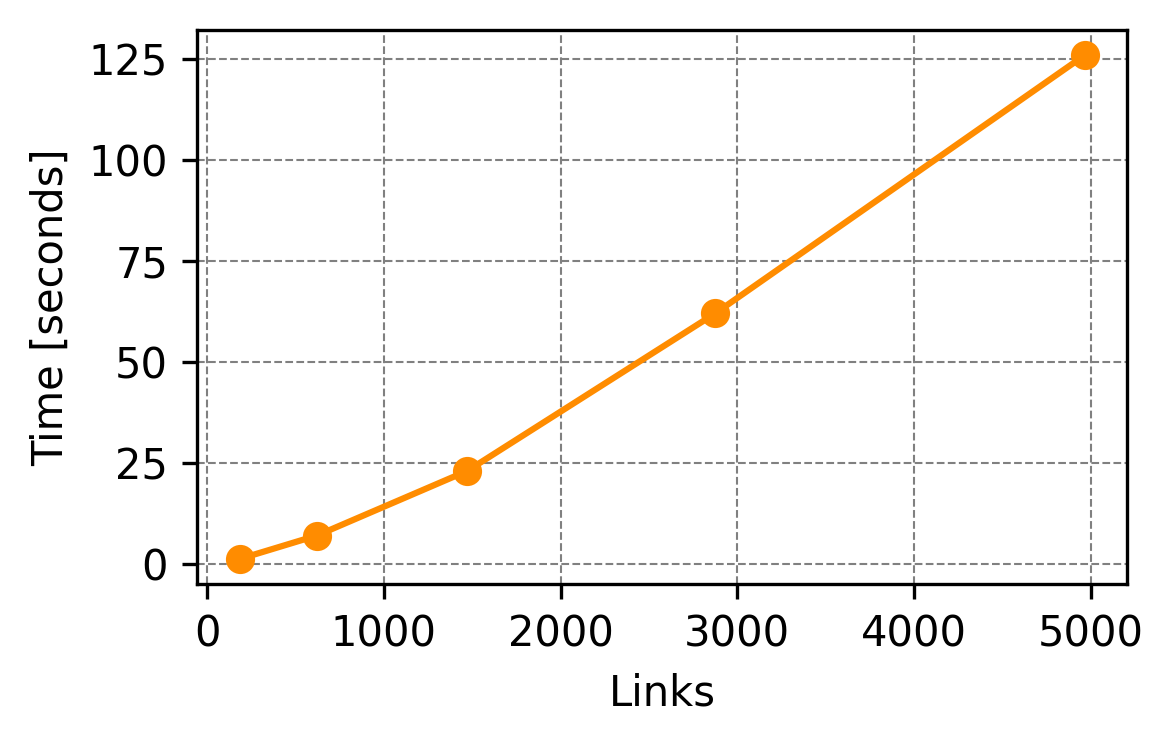

In [ ]:
def scalability_by_links():
    """_summary_
    """
    time_y: list[float] = [x.tm.total_seconds() for x in data_var_top]
    link_x: list[int] = [x.links  for x in data_var_top]

    plt.title("")
    plt.figure(figsize=(5 * 8/10, 3 * 8/10))
    plt.plot(link_x, time_y, color="darkorange", marker="o")
    plt.xlabel("Links")
    plt.ylabel("Time [seconds]")
    plt.grid(True, which='major', axis='both', linestyle='--', linewidth=0.5, color='gray')
    plt.savefig("scaling_by_links.png", dpi=300, bbox_inches='tight')

    # Show the plot
    plt.show()
scalability_by_links()

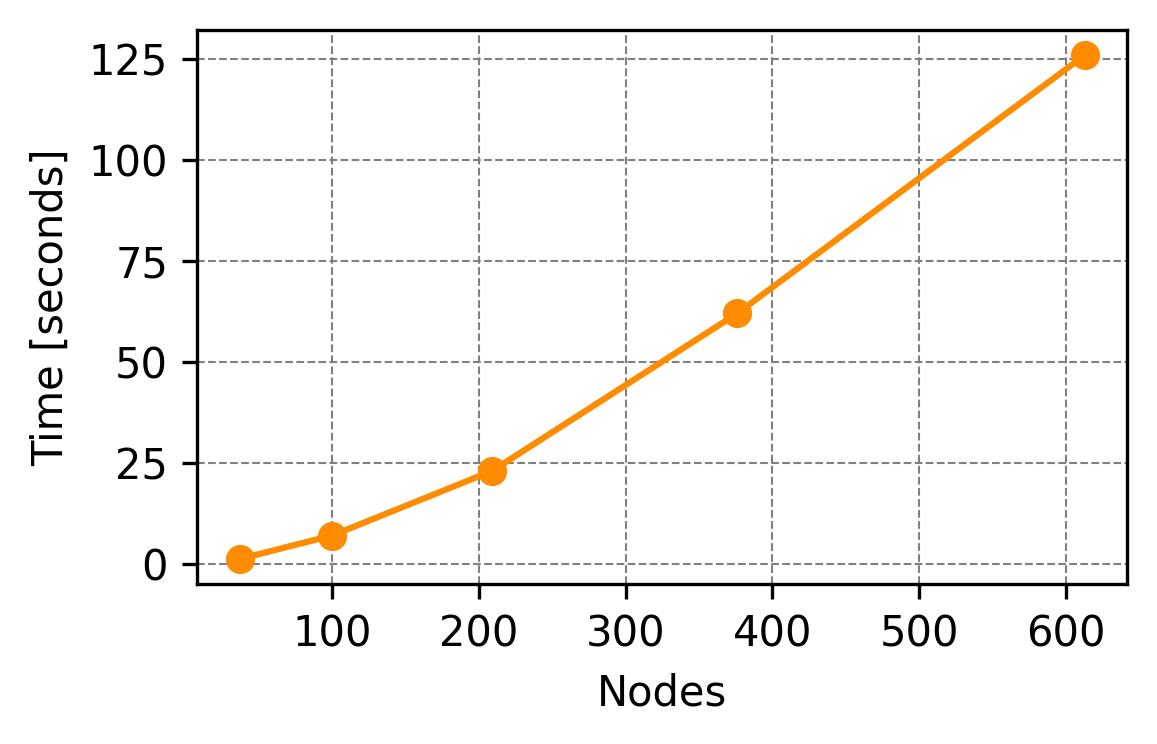

In [58]:
def scalability_by_nodes():
    """_summary_
    """
    time_y: list[float] = [x.tm.total_seconds() for x in data_var_top]
    nodes_x: list[int] = [x.nodes  for x in data_var_top]

    plt.figure(figsize=(5 * 8/10, 3 * 8/10))
    plt.plot(nodes_x, time_y, color="darkorange", marker="o")
    plt.xlabel("Nodes")
    plt.ylabel("Time [seconds]")
    plt.grid(True, which='major', axis='both', linestyle='--', linewidth=0.5, color='gray')
    plt.savefig("scaling_by_nodes.png", dpi=300, bbox_inches='tight')
    plt.show()
    
scalability_by_nodes()

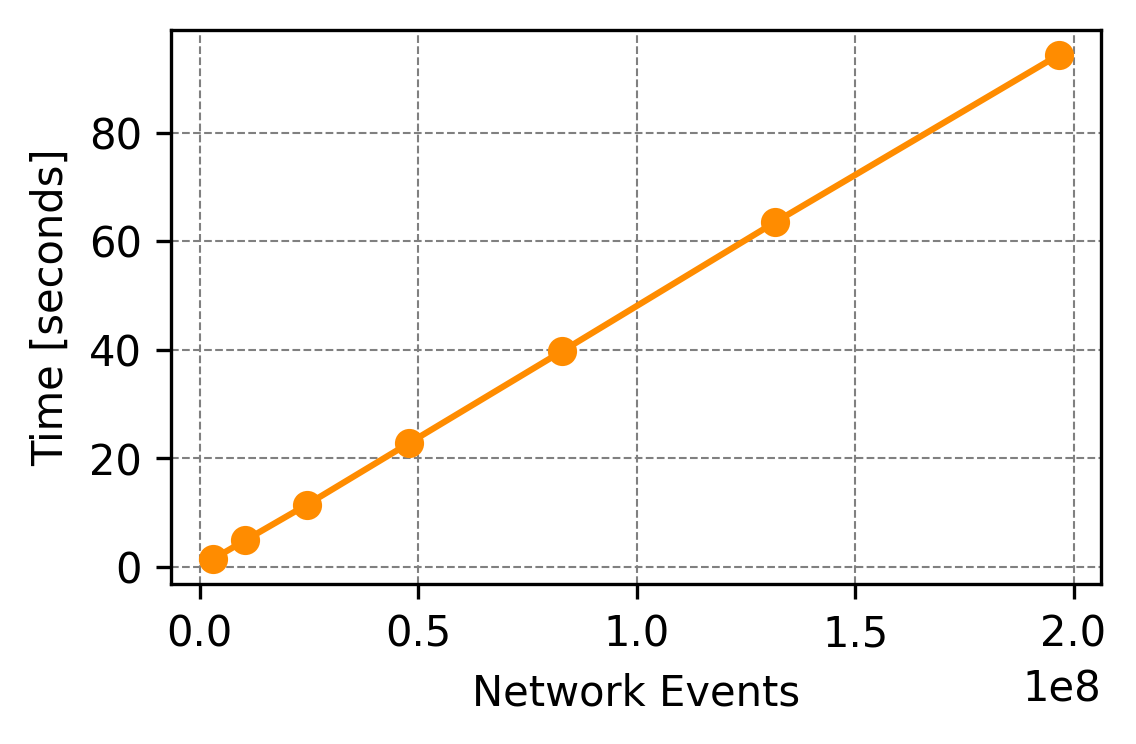

In [57]:
def scalability_by_netevents():
    """_summary_
    """
    time_y: list[float] = [x.tm.total_seconds() for x in data_var_events]
    events_x: list[int] = [x.events  for x in data_var_events]

    plt.figure(figsize=(5 * 8/10, 3 * 8/10))
    plt.plot(events_x, time_y, color="darkorange", marker="o")
    plt.xlabel("Network Events")
    plt.ylabel("Time [seconds]")
    plt.grid(True, which='major', axis='both', linestyle='--', linewidth=0.5, color='gray')
    plt.savefig("scaling_by_events.png", dpi=300, bbox_inches='tight')
    plt.show()

scalability_by_netevents()

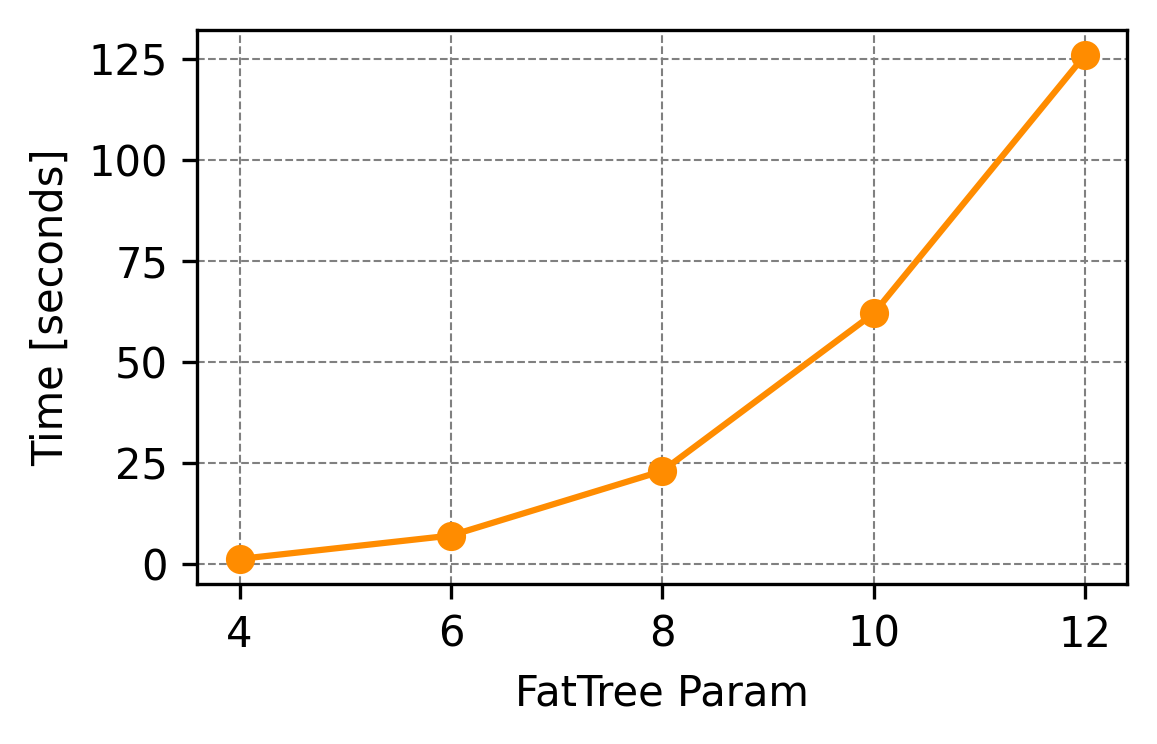

In [56]:
def scalability_by_n_fattree():
    """_summary_
    """
    def hosts_to_n_fattree(hosts: int) -> int:
        match hosts:
            case 16: return 4
            case 54: return 6
            case 128: return 8
            case 250: return 10
            case 432: return 12
    
    time_y: list[float] = [x.tm.total_seconds() for x in data_var_top]
    n_x: list[int] = [hosts_to_n_fattree(x.hosts)  for x in data_var_top]

    plt.figure(figsize=(5 * 8/10, 3 * 8/10))
    plt.plot(n_x, time_y, color="darkorange", marker="o")
    plt.xlabel("FatTree Param")
    plt.ylabel("Time [seconds]")
    plt.grid(True, which='major', axis='both', linestyle='--', linewidth=0.5, color='gray')
    plt.savefig("scaling_by_fattree_param.png", dpi=300, bbox_inches='tight')
    plt.show()
    
scalability_by_n_fattree()

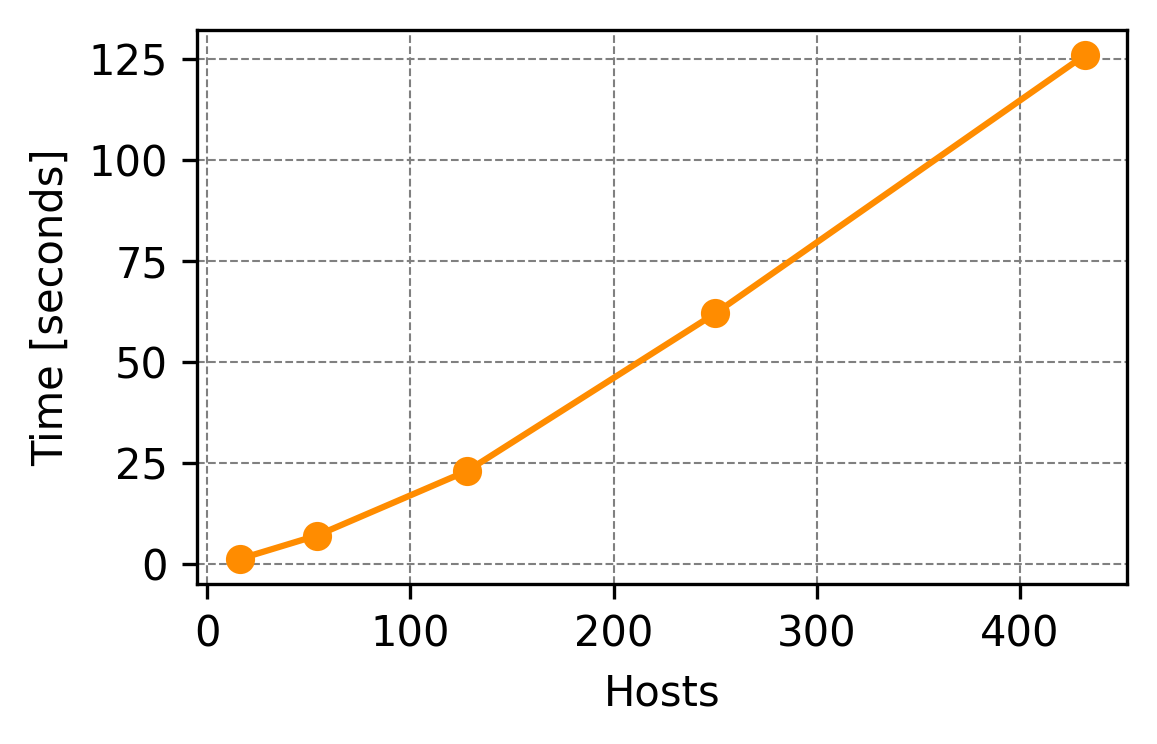

In [55]:
def scalability_by_hosts():
    """_summary_
    """
    time_y: list[float] = [x.tm.total_seconds() for x in data_var_top]
    hosts_x: list[int] = [x.hosts  for x in data_var_top]

    plt.figure(figsize=(5 * 8/10, 3 * 8/10))
    plt.plot(hosts_x, time_y, color="darkorange", marker="o")
    plt.xlabel("Hosts")
    plt.ylabel("Time [seconds]")
    plt.grid(True, which='major', axis='both', linestyle='--', linewidth=0.5, color='gray')
    plt.savefig("scaling_by_hosts.png", dpi=300, bbox_inches='tight')
    plt.show()
    
scalability_by_hosts()